In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Part 1

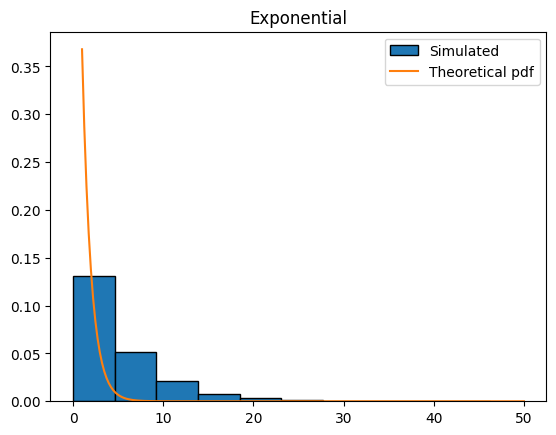

In [35]:
# A) Exponential dist
U = np.random.uniform(size=10_000)
lam = 0.2
Y_exp = -np.log(U)/lam

# Plot
plt.hist(Y_exp,density=True, edgecolor="black", label="Simulated")
x = np.linspace(1,50,200)
plt.plot(x, ss.expon.pdf(x), label="Theoretical pdf")
plt.legend()
plt.title("Exponential")
plt.show()

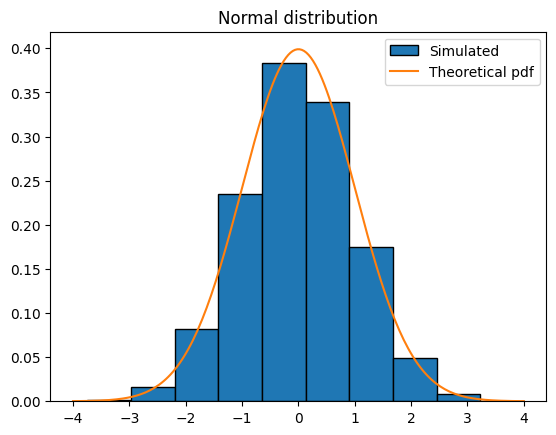

In [36]:
# B) Normal distribution (at least with standard Box-Mueller)
U = np.random.uniform(size=(2,5_000))
Z_norm = (np.sqrt(-2*np.log(U[0])) * np.array([np.cos(2 * np.pi * U[1]), 
                                              np.sin(2 * np.pi * U[1])])).reshape(-1)

# Plot
plt.hist(Z_norm,density=True, edgecolor="black", label="Simulated")
x = np.linspace(-4,4,200)
plt.plot(x, ss.norm.pdf(x), label="Theoretical pdf")
plt.legend()
plt.title("Normal distribution")
plt.show()

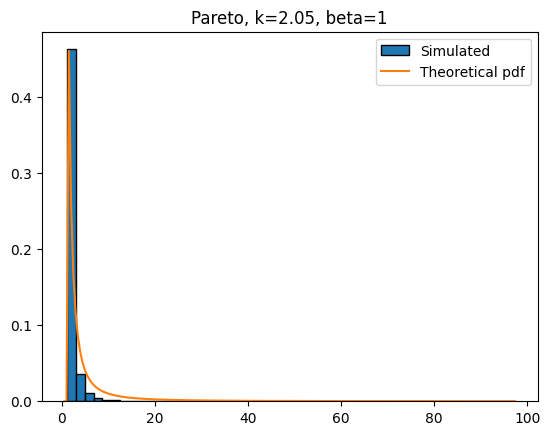

Theoretical mean: 1.9523809523809526, var: 37.18820861678019
Observed mean: 1.9178579212283184, var: 4.780744840265045


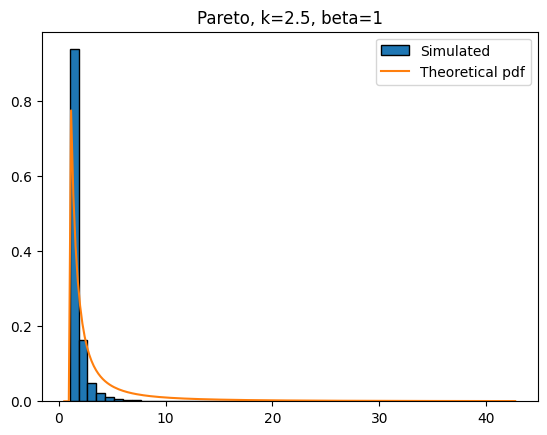

Theoretical mean: 1.6666666666666667, var: 2.2222222222222223
Observed mean: 1.6496908685467715, var: 1.44841897378652


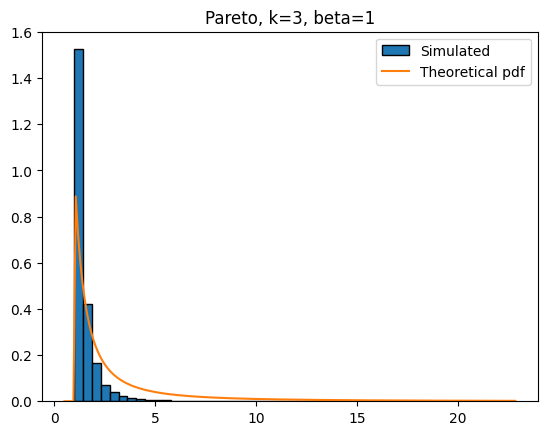

Theoretical mean: 1.5, var: 0.75
Observed mean: 1.4900078511641104, var: 0.603353490464017


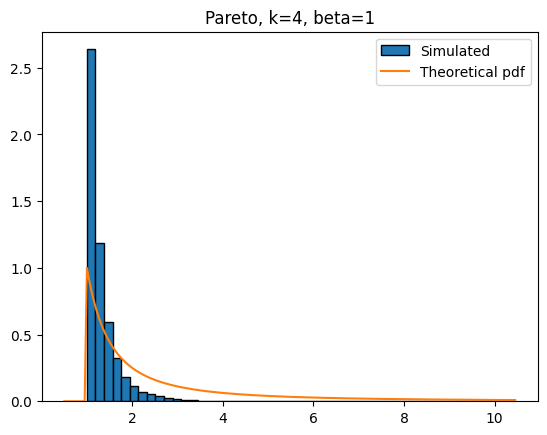

Theoretical mean: 1.3333333333333333, var: 0.2222222222222222
Observed mean: 1.3282947264109617, var: 0.19742096917341276


In [40]:
# C) Pareto distribution
beta = 1
k = [2.05, 2.5, 3, 4]
U = np.random.uniform(size=10_000)
for i in range(len(k)):
    ki = k[i]
    # Simulate
    Y_pareto = beta * (U**(-1/ki))

    ###
    # PART 2
    ###
    # Calc theoretical mean and variance
    mean_theo = beta * ki/(ki - 1)
    var_theo = beta**2 * (ki)/((ki-1)**2 * (ki-2))

    # Calc observed mean and var
    mean = np.mean(Y_pareto)
    var = np.var(Y_pareto)

    # Plot
    plt.hist(Y_pareto,density=True,bins=50, edgecolor="black", label="Simulated")
    x = np.linspace(0.5,np.max(Y_pareto),200)
    plt.plot(x, ss.pareto.pdf(x,beta), label="Theoretical pdf")
    plt.legend()
    plt.title(f"Pareto, k={ki}, beta=1")
    plt.show()

    print(f"Theoretical mean: {mean_theo}, var: {var_theo}")
    print(f"Observed mean: {mean}, var: {var}")

# Part 3

In [102]:
MEAN = []
VAR = []
np.random.seed(420)

# calc observed mean and var
for i in range(100):
    U = np.random.uniform(size=(2,5))
    Z_norm = (np.sqrt(-2*np.log(U[0])) * np.array([np.cos(2 * np.pi * U[1]), 
                                                np.sin(2 * np.pi * U[1])])).reshape(-1)
    
    MEAN.append(np.mean(Z_norm))
    VAR.append(np.var(Z_norm))

# Calc CI
MEAN_CI = []
VAR_CI = []
n_obs = 10
df = n_obs - 1
tcrit = ss.t.ppf(0.975,df=df)
chi2_lower = ss.chi2.ppf(0.05/2, df)
chi2_upper = ss.chi2.ppf(1 - 0.05/2, df)

for i in range(100):
    s = np.sqrt(VAR[i])
    margin = tcrit * s / np.sqrt(n_obs)

    ci = np.array([MEAN[i] - margin,
                   MEAN[i] + margin])

    MEAN_CI.append(ci)

    ci = np.array([df * s**2 / chi2_upper,
                   df * s**2 / chi2_lower])
    VAR_CI.append(ci)



MEAN_CI = np.concat(MEAN_CI).reshape((100,2))
VAR_CI = np.concat(VAR_CI).reshape((100,2))

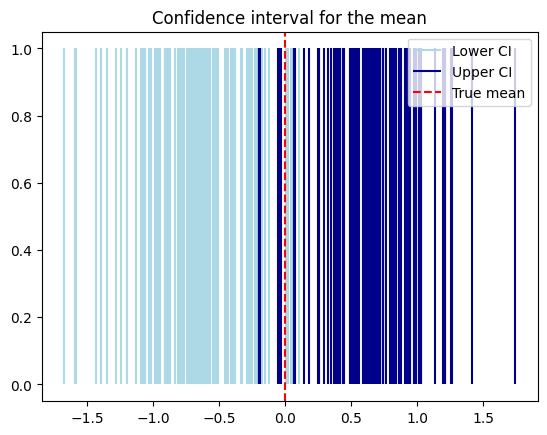

In [103]:
# MEAN CONFIDENCE INTERVAL
plt.vlines(MEAN_CI[:,0],0,1,color="lightblue", label="Lower CI")
plt.vlines(MEAN_CI[:,1],0,1,color="darkblue", label="Upper CI")

plt.axvline(0, color='red', linestyle='--', label="True mean")  # true mean
plt.title("Confidence interval for the mean")
plt.legend()
plt.show()

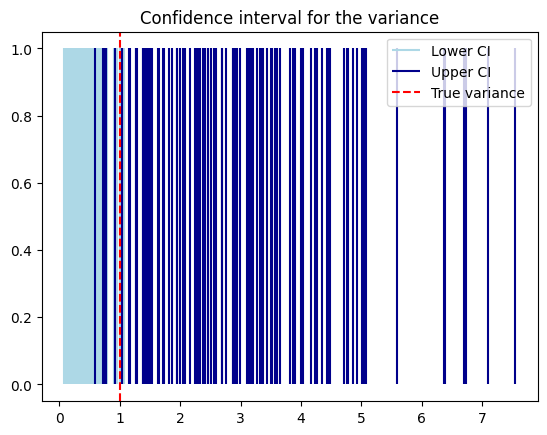

In [106]:
# VARIANCE CONFIDENCE INTERVAL
plt.vlines(VAR_CI[:,0],0,1,color="lightblue", label="Lower CI")
plt.vlines(VAR_CI[:,1],0,1,color="darkblue", label="Upper CI")

plt.axvline(1, color='red', linestyle='--', label="True variance")  # true mean
plt.title("Confidence interval for the variance")
plt.legend()
plt.show()

In [110]:
# Coverage MEAN
num = (MEAN_CI[:,0] <= 0) & (MEAN_CI[:,1] >= 0)
print(f"Coverage mean: {np.sum(num)/100}")

# Coverage variance
num = (VAR_CI[:,0] <= 1) & (VAR_CI[:,1] >= 1)
print(f"Coverage variance: {np.sum(num)/100}")

Coverage mean: 0.89
Coverage variance: 0.93


# Part 4

In [113]:
N = 10_000
beta = 1
mu = beta
U1 = np.random.uniform(low=0, high=1, size=N)
U2 = np.random.uniform(low=0, high=1, size=N)
Y = - np.log(U1)/lam
X_pareto_comp = - np.log(U2)/Y

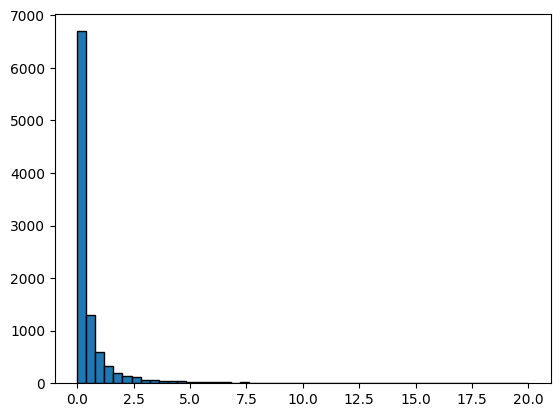

In [114]:
plt.hist(X_pareto_comp, bins=50, range=(0,20), edgecolor='black')
plt.show()